<a href="https://www.kaggle.com/code/sonawanelalitsunil/motor-vehicle-repair-towing-services-98-97-ml?scriptVersionId=234233584" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/motor-vehicle-repair-and-towing/Motor_Vehicle_Repair_and_Towing.csv


## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/motor-vehicle-repair-and-towing/Motor_Vehicle_Repair_and_Towing.csv')

In [3]:
df.head()

,Registration Type,Corporation Name,Trade Name,Business Address,Business Address2,City,State,Zip,Phone Number,# ASE Certified Mechanics,Tow Storage Address,Tow Storage 2,Tow Storage City,Tow Storage State,Tow Storage Zip,Tow Storage Phone,Issue Date,Expiration,Registration No.,Location
0,Corporation,MG Auto & Truck Repair Services LLC,MG Auto & Truck Repair Services LLC,8146 Beechcraft Ave.,8146,Gaithersburg,MD,20879,(301) 848-1294,0,NaN,NaN,NaN,NaN,NaN,NaN,12/11/2024,12/11/2025,19-MT-002754,"8146 Beechcraft Ave.\nGaithersburg, MD 20879\n..."
1,Corporation,"E & S Towing Services, Inc.",E & S Towing Service,15814 Paramount Dr,NaN,Rockville,MD,20855,(240) 304-9367,0,15814 Paramount Dr,NaN,Rockville,MD,20906,(240) 304-9367,12/02/2024,12/02/2025,20-MT-005316,"15814 Paramount Dr\nRockville, MD 20855\n(39.1..."
2,Corporation,"Mohamed M. Kheiry, LLC",Satellite Motors,8109 Mayor Lane,NaN,Silver Spring,MD,20910,(301) 585-7876,0,NaN,NaN,NaN,NaN,NaN,NaN,12/22/2024,12/22/2027,17-MT-001433,"8109 Mayor Lane\nSilver Spring, MD 20910\n(38...."
3,Corporation,"Kasparian, Inc.",Kelley's Auto Body,10644 Connecticut Ave,NaN,Kensington,MD,20895,(301) 946-0051,0,NaN,NaN,NaN,NaN,NaN,NaN,01/26/2025,01/26/2028,16-MT-000371,"10644 Connecticut Ave\nKensington, MD 20895\n(..."
4,Corporation,"Dustin, Inc.",Burnt Mills BP Servicenter,10711 Columbia Pike,NaN,Silver Spring,MD,20901,(301) 593-1036,0,NaN,NaN,NaN,NaN,NaN,NaN,12/04/2024,12/04/2027,15-MT-000436,"10711 Columbia Pike\nSilver Spring, MD 20901\n..."


In [4]:
df.tail()

,Registration Type,Corporation Name,Trade Name,Business Address,Business Address2,City,State,Zip,Phone Number,# ASE Certified Mechanics,Tow Storage Address,Tow Storage 2,Tow Storage City,Tow Storage State,Tow Storage Zip,Tow Storage Phone,Issue Date,Expiration,Registration No.,Location
2427,Corporation,"Towmasters, Inc.",A & R Automotive,1130 East-West Hwy.,NaN,Silver Spring,MD,NaN,(301) 949-6100,1,NaN,NaN,NaN,NaN,NaN,NaN,11/27/1989,11/27/1992,89-MT-000298,"1130 East-West Hwy.\nSilver Spring, MD\n(38.98..."
2428,Corporation,"Chevy Chase Imports, Inc.",Chevy Chase Mitsubishi,7701 Wisconsin Avenue,NaN,Bethesda,MD,NaN,(301) 656-9200,2,NaN,NaN,NaN,NaN,NaN,NaN,09/08/1998,09/08/2001,98-MT-000695,"7701 Wisconsin Avenue\nBethesda, MD\n(38.98672..."
2429,Corporation,J & D Auto Service Inc.,"J & D Auto Service, Inc.",18909 Bonanza Way,NaN,Gaithersburg,MD,NaN,(301) 840-8556,0,NaN,NaN,NaN,NaN,NaN,NaN,03/29/2010,03/29/2013,10-MT-000516,"18909 Bonanza Way\nGaithersburg, MD\n(39.16647..."
2430,Corporation,"AASELUC Auto Clinic, LLC","AASELUC Auto Clinic, LLC",12909 Falling Water Cir,102,Germantown,MD,20874,(240) 938-9892,0,NaN,NaN,NaN,NaN,NaN,NaN,01/06/2021,01/06/2024,18-MT-002233,"12909 Falling Water Cir\nGermantown, MD 20874\..."
2431,Corporation,"Auto Adventure, Inc.",C & C Towing,"8115 Fenton Street, Suite 306-A",NaN,Silver Spring,MD,NaN,(301) 589-2403,0,8114 Fenton Street Suite 306-A,NaN,Silver Spring,MD,20910-,NaN,08/18/2004,03/11/2007,04-MT-000680,"8115 Fenton Street, Suite 306-A\nSilver Spring..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2432 entries, 0 to 2431
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Registration Type          2432 non-null   object
 1   Corporation Name           1818 non-null   object
 2   Trade Name                 2428 non-null   object
 3   Business Address           2353 non-null   object
 4   Business Address2          116 non-null    object
 5   City                       2389 non-null   object
 6   State                      2389 non-null   object
 7   Zip                        1301 non-null   object
 8   Phone Number               2377 non-null   object
 9   # ASE Certified Mechanics  2432 non-null   int64 
 10  Tow Storage Address        248 non-null    object
 11  Tow Storage 2              12 non-null     object
 12  Tow Storage City           208 non-null    object
 13  Tow Storage State          207 non-null    object
 14  Tow Stor

In [6]:
df.describe()

,# ASE Certified Mechanics
count,2432.000000
mean,0.372944
std,1.306053
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,25.000000


In [7]:
df.isnull().sum()

Registration Type               0
Corporation Name              614
Trade Name                      4
Business Address               79
Business Address2            2316
City                           43
State                          43
Zip                          1131
Phone Number                   55
# ASE Certified Mechanics       0
Tow Storage Address          2184
Tow Storage 2                2420
Tow Storage City             2224
Tow Storage State            2225
Tow Storage Zip              2227
Tow Storage Phone            2254
Issue Date                      0
Expiration                      0
Registration No.                0
Location                       43
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum().sum()

17862

In [10]:
df.dtypes

Registration Type            object
Corporation Name             object
Trade Name                   object
Business Address             object
Business Address2            object
City                         object
State                        object
Zip                          object
Phone Number                 object
# ASE Certified Mechanics     int64
Tow Storage Address          object
Tow Storage 2                object
Tow Storage City             object
Tow Storage State            object
Tow Storage Zip              object
Tow Storage Phone            object
Issue Date                   object
Expiration                   object
Registration No.             object
Location                     object
dtype: object

In [11]:
df.columns

Index(['Registration Type', 'Corporation Name', 'Trade Name',
       'Business Address', 'Business Address2', 'City', 'State', 'Zip',
       'Phone Number', '# ASE Certified Mechanics', 'Tow Storage Address ',
       'Tow Storage 2', 'Tow Storage City', 'Tow Storage State',
       'Tow Storage Zip', 'Tow Storage Phone', 'Issue Date', 'Expiration',
       'Registration No.', 'Location'],
      dtype='object')

## Data visualizations

In [12]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


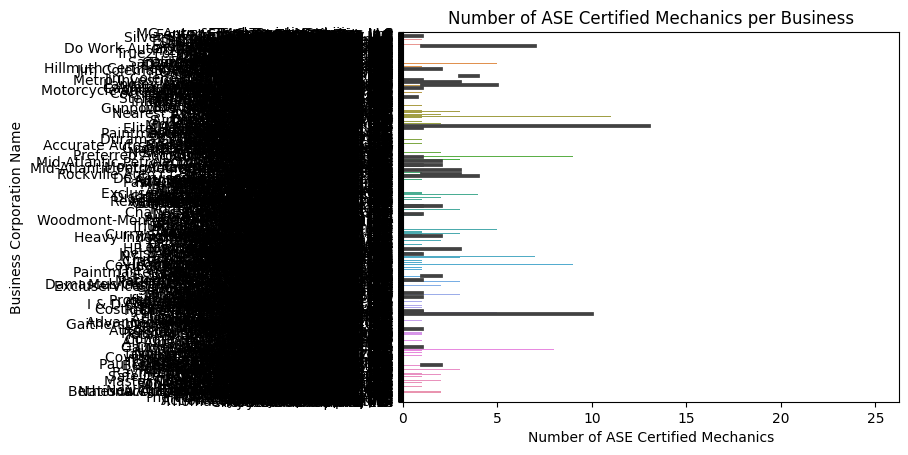

In [13]:
sns.barplot(x='# ASE Certified Mechanics', y='Corporation Name', data=df)
plt.title('Number of ASE Certified Mechanics per Business')
plt.xlabel('Number of ASE Certified Mechanics')
plt.ylabel('Business Corporation Name')
plt.show()

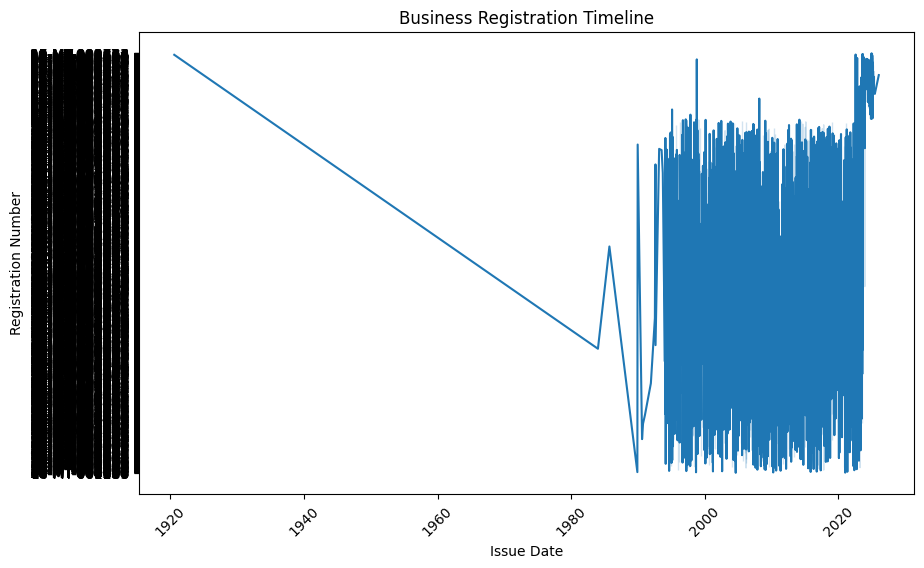

In [14]:
# 3. Business Registration Expiry (Timeline Plot)
df['Issue Date'] = pd.to_datetime(df['Issue Date'])
df['Expiration'] = pd.to_datetime(df['Expiration'])

# Plot the issue date and expiration date as a timeline
plt.figure(figsize=(10, 6))
sns.lineplot(x='Issue Date', y='Registration No.', data=df)
plt.title('Business Registration Timeline')
plt.xlabel('Issue Date')
plt.ylabel('Registration Number')
plt.xticks(rotation=45)
plt.show()

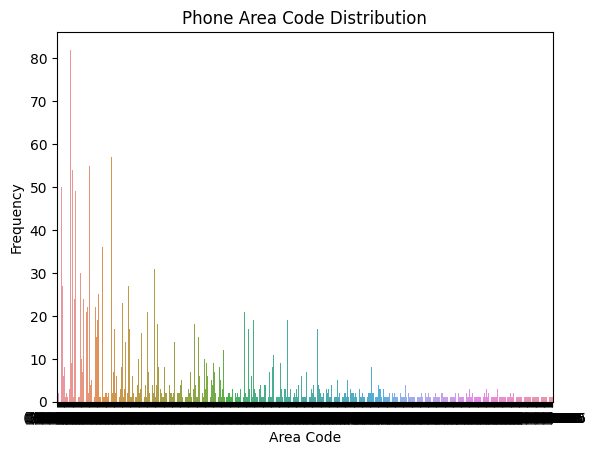

In [15]:
# 4. Phone Number Distribution (Histogram)
df['Phone Number'] = df['Phone Number'].astype(str)  # In case phone numbers need to be treated as strings
phone_area_codes = df['Phone Number'].apply(lambda x: x.split('-')[0])  # Assuming phone numbers have '-' separators
sns.countplot(x=phone_area_codes)
plt.title('Phone Area Code Distribution')
plt.xlabel('Area Code')
plt.ylabel('Frequency')
plt.show()


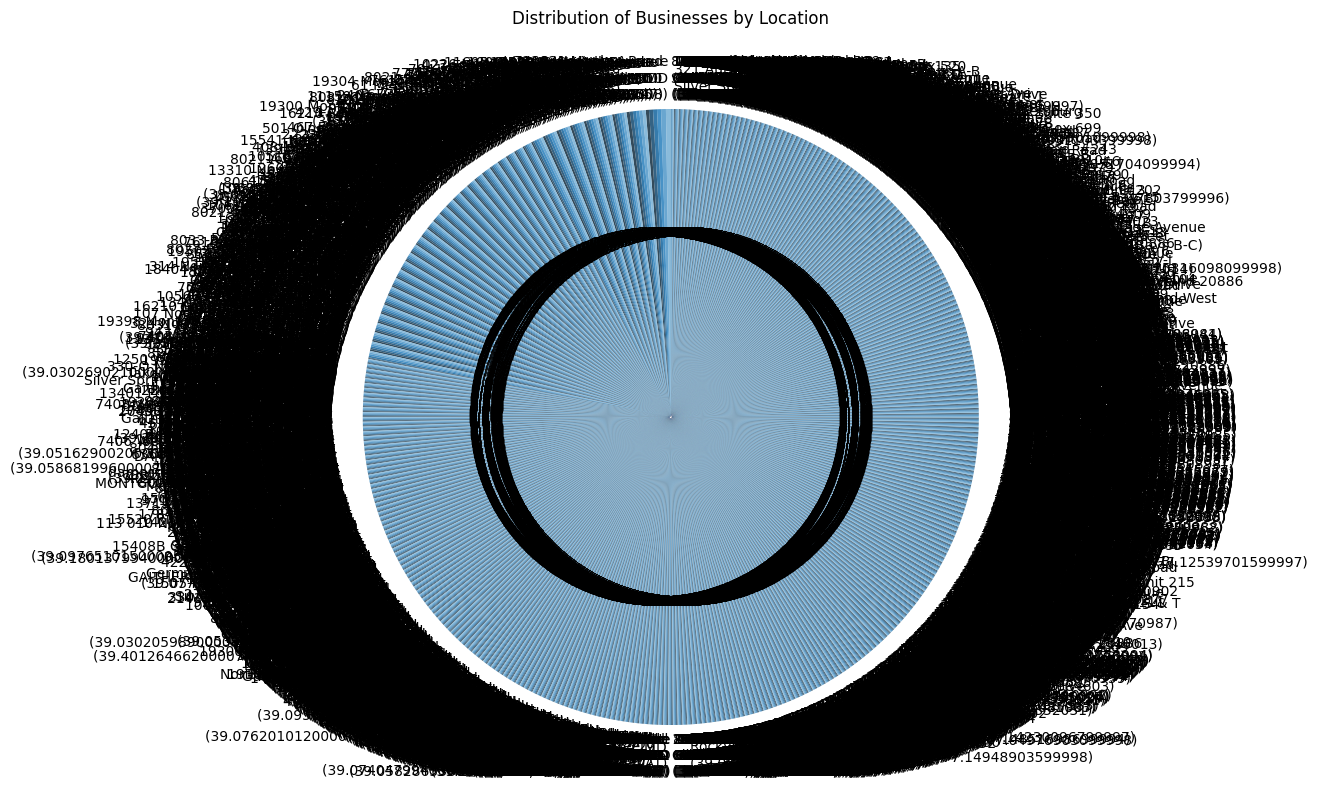

In [16]:
location_counts = df['Location'].value_counts()
location_counts.plot.pie(autopct='%1.1f%%', figsize=(15, 10), startangle=90, colors=sns.color_palette('Blues_d'))
plt.title('Distribution of Businesses by Location')
plt.ylabel('')
plt.show()


## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [18]:
# Identify DateTime columns
datetime_columns = df.select_dtypes(include=['datetime']).columns

# Convert DateTime columns to numeric (days since the earliest date)
for column in datetime_columns:
    df[column] = (df[column] - df[column].min()).dt.days

# Let's consider a target column, for this example, we assume 'Registration Type' is the target.
# Replace this with the actual target column name in your dataset.
target_column = 'Registration Type'

# Identify feature columns (all columns except the target)
feature_columns = df.columns[df.columns != target_column]

# Label Encoding for categorical columns
label_encoder = LabelEncoder()

# Apply label encoding for all categorical columns
for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

# Split the dataset into X (features) and y (target)
X = df[feature_columns]
y = df[target_column]

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

Logistic Regression Accuracy: 94.46%


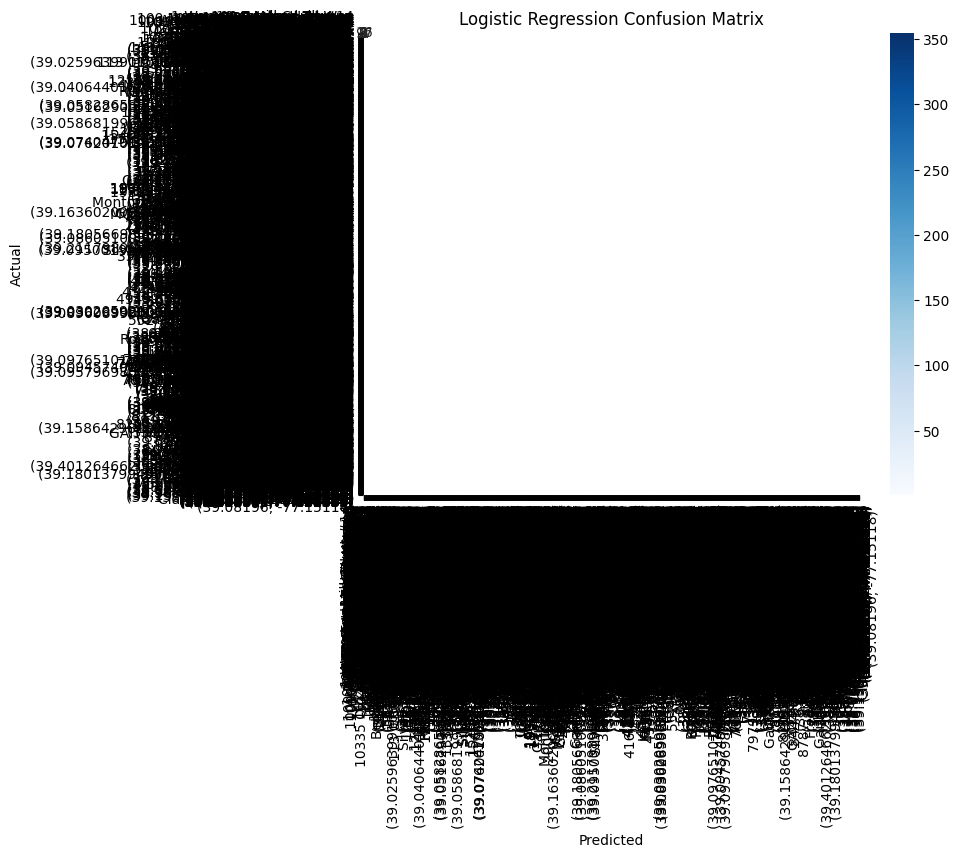

Random Forest Accuracy: 98.97%


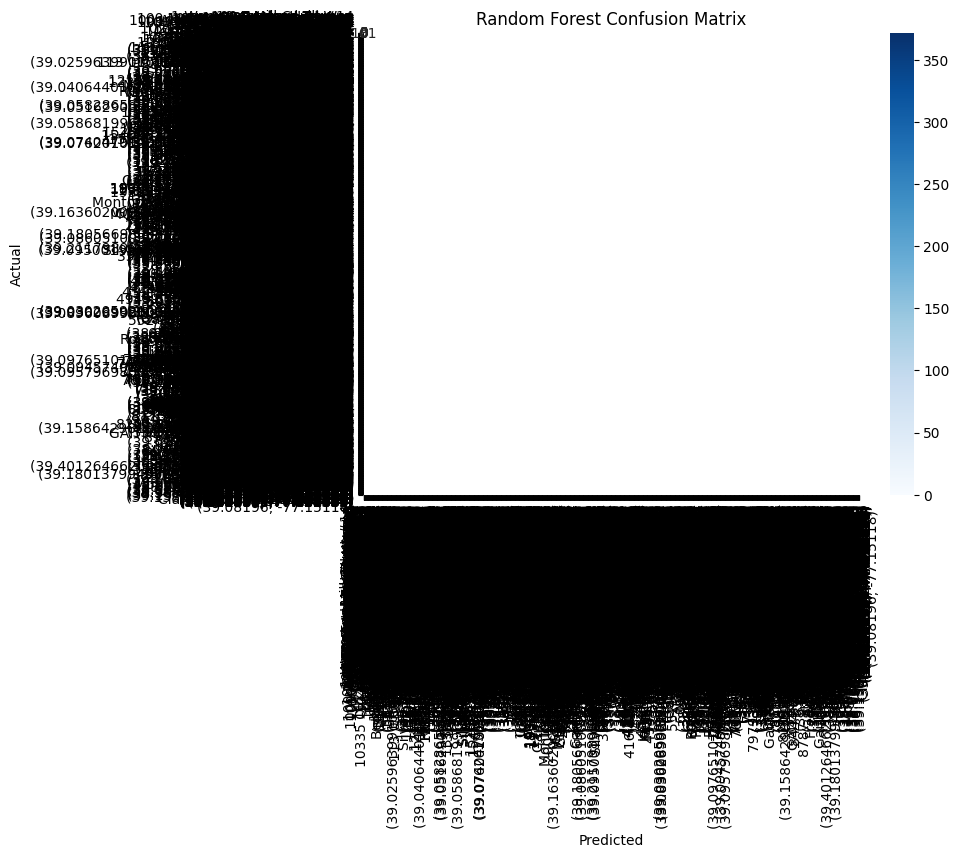

SVM Accuracy: 76.39%


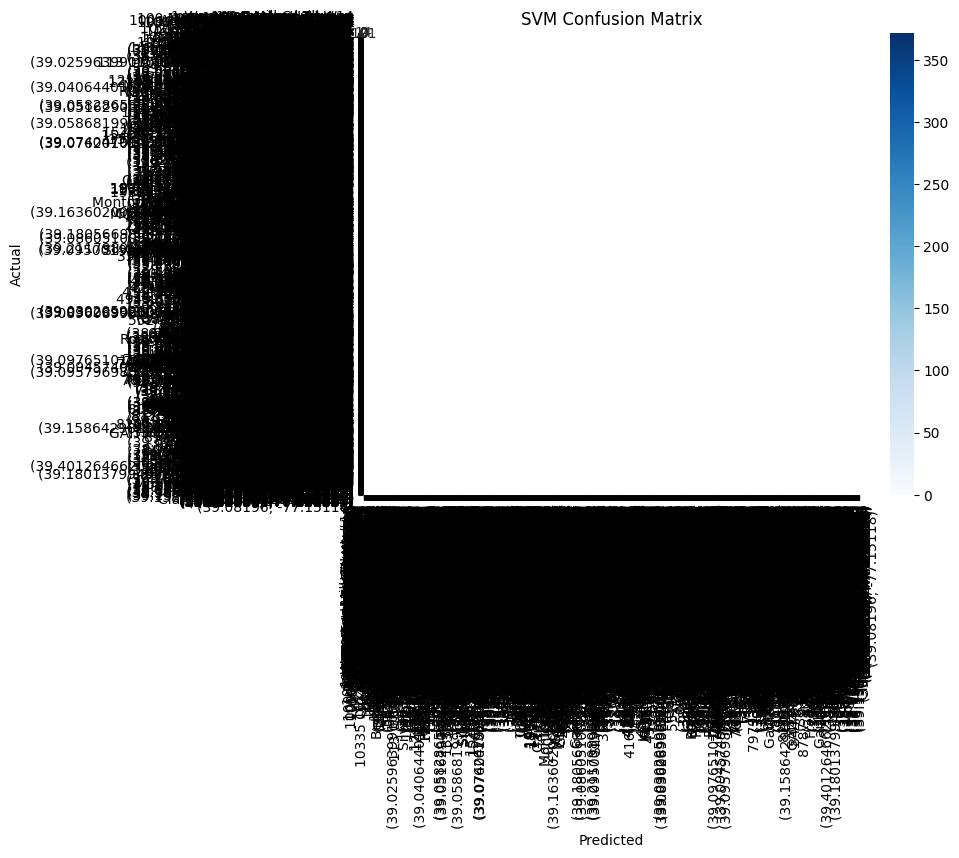

In [20]:
# Train the models, make predictions, and evaluate performance
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy * 100:.2f}%")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Get the unique classes for labeling axes
    classes = label_encoder.classes_
    
    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Thank you...pls upvote!!